## Load Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Resizing, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
import cv2 as cv
import os
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # to hide tf warning

## Load Image File

In [2]:
data_dir = "Vehicles"

for root, dirs, files in os.walk(data_dir):
    for file in files:
        path = os.path.join(root, file)   #make full path of a image
        img = cv.imread(path)             #read image with CV2 and return numpy array. without image return None
        if img is None:
            print('Removing', path)       
            os.remove(path)             #remove corrupted image permanently

libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


In [3]:
image_size = 224     #image size of EfficientNetV2B0 (224,224)
batch_size = 32
channel = 3         # for RGB color channel

In [4]:
dataset = image_dataset_from_directory('Vehicles',
                                      shuffle = True,
                                      image_size=(image_size, image_size),
                                      batch_size= batch_size
                                      )

Found 5588 files belonging to 7 classes.


In [5]:
class_names = dataset.class_names   # to find vehicles name

In [6]:
class_names

['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']

In [7]:
len(dataset) #batch len

175

In [8]:
175*32

5600

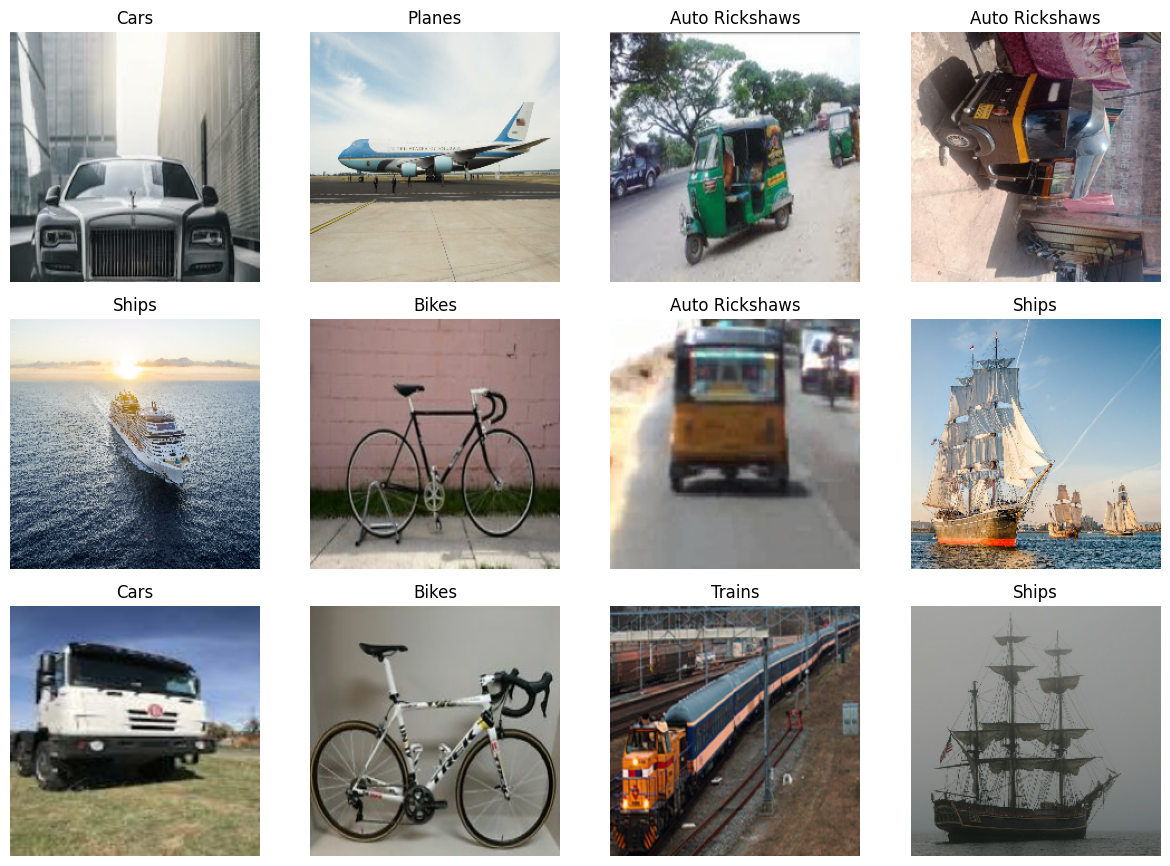

In [9]:
plt.figure(figsize = (12,9))
for image_batch, label_batch in dataset.take(1):  #take data from batch 1
    for i in range(12):
      plt.subplot(3,4,i+1)
      plt.title(class_names[int(label_batch[i])])
      plt.imshow(image_batch[i].numpy().astype('uint8'))
      plt.tight_layout()
      plt.axis('off')

## Splite and Separate the image into train, val, and test data set

In [10]:
def split_data(ds,
              train_split = 0.8,     # 80% data for trainung
              val_split = 0.1,       # 10% data for validation
              test_split = 0.1,      # 10 % data for test
              shuffle = True,
              shuffle_size = 10000,
              seed = 12):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(buffer_size = shuffle_size, seed = seed)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)              # take 80 % from dataset
    val_ds = ds.skip(train_size).take(val_size) # skip 80% train data and take 10%
    test_ds = ds.skip(train_size + val_size)    # skip (80%+10%)train and val dataset and take rest 10%
    return train_ds, val_ds, test_ds

In [11]:
train_ds, val_ds, test_ds = split_data(dataset)   # call the function and return train, val, test dataset

In [12]:
print('Lenght of Train Dataset:', len(train_ds))     #total trainable data (140*32)=4480
print('Lenght of Validation Dataset:', len(val_ds))  #total validation data (17*32)=544
print('Lenght of Test Dataset:', len(test_ds))       #total trainable data (18*32)=576

Lenght of Train Dataset: 140
Lenght of Validation Dataset: 17
Lenght of Test Dataset: 18


## Image Preprocessing 

In [13]:
AUTOTUNE = tf.data.AUTOTUNE     #to ready next batch while present batch is working 

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE) #use cache to load dataset into RAM, for fast training 
val_ds = val_ds.cache().prefetch(AUTOTUNE) 
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [14]:
data_augmentation = Sequential([    #convert image into different style
    RandomFlip('horizontal'),
    RandomRotation(0.2),
    RandomZoom(0.1)
])

## Load Model

In [15]:
conv_base = EfficientNetV2B0(
    weights='imagenet',
    include_top= False,
    input_shape=(224, 224, 3)
)

In [16]:
conv_base.trainable = False     #frezz the base layer

In [17]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),  #take intput in (224,224) shape
    data_augmentation,                  # augmentation image
    layers.Lambda(preprocess_input),    # rescale the image(1/255) for efficientnetv2
    conv_base,                          # EfficientNetV2 layer
    layers.GlobalAveragePooling2D(),    # summarize each feature map by taking average
    layers.Dense(256, activation='relu'), # fully connected (dense) layer with 256 neurons
    layers.Dropout(0.5),                   # reduce overfitting by dropping randomly 50% neurons during training
    layers.Dense(7, activation = 'softmax') # activation foftmax for multiclass classification
])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,249,047 (23.84 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [19]:
model.compile(
    optimizer='adam',
    loss ='sparse_categorical_crossentropy',  # loss function for multi-class classification(sparse categorical crossentropy)
    metrics = ['accuracy']
)

## Fit Model

In [20]:
history = model.fit(
    train_ds, 
    validation_data= val_ds,
    epochs = 10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 143s 890ms/step - accuracy: 0.8926 - loss: 0.3355 - val_accuracy: 0.9890 - val_loss: 0.0385
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 705ms/step - accuracy: 0.9517 - loss: 0.1431 - val_accuracy: 0.9908 - val_loss: 0.0249
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 105s 751ms/step - accuracy: 0.9581 - loss: 0.1219 - val_accuracy: 0.9945 - val_loss: 0.0198
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 684ms/step - accuracy: 0.9635 - loss: 0.1017 - val_accuracy: 0.9982 - val_loss: 0.0149
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 681ms/step - accuracy: 0.9736 - loss: 0.0838 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 688ms/step - accuracy: 0.9671 - loss: 0.0952 - val_accuracy: 0.9982 - val_loss: 0.0087
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 681ms/step - accuracy: 0.9722 - loss: 0.0817 - val_accuracy: 0.9908 - val_loss: 0.0182
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 686ms/step - accuracy: 0.9740 - loss:

## Accuracy and Prediction

In [21]:
accurcy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

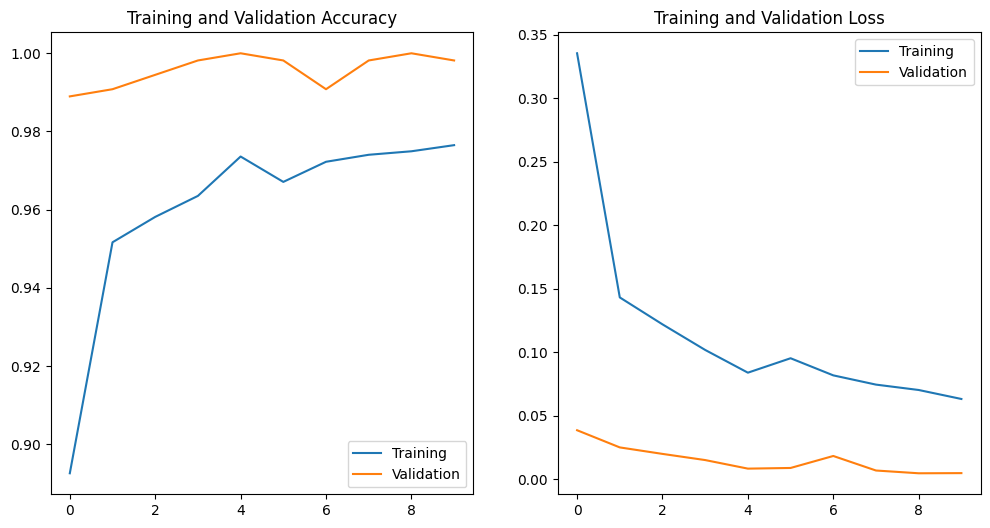

In [22]:
plt.figure(figsize = (12,6))
plt.subplot(1, 2 ,1)
plt.plot(accurcy, label = 'Training')
plt.plot(val_accuracy, label = 'Validation')
plt.legend('lower right')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2 ,2)
plt.plot(loss, label = 'Training')
plt.plot(val_loss, label = 'Validation')
plt.legend('upper right')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [23]:
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("Final Training Accuracy:", final_train_accuracy)
print("Final Validation Accuracy:", final_val_accuracy)
print()
print("Final Training Loss:", final_train_loss)
print("Final Validation Loss:", final_val_loss)

Final Training Accuracy: 0.9764995574951172
Final Validation Accuracy: 0.998161792755127

Final Training Loss: 0.06308288127183914
Final Validation Loss: 0.004661588929593563


In [24]:
score = model.evaluate(test_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 526ms/step - accuracy: 0.9982 - loss: 0.0061


In [25]:
print("Test Accuracy:", score[1])
print("Test Loss:", score[0])

Test Accuracy: 0.9982269406318665
Test Loss: 0.0061139315366744995


First Image to Predict
Actual Label: Planes
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Label: Planes


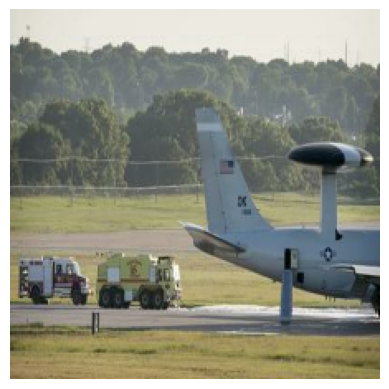

In [26]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()
    print("First Image to Predict")
    plt.imshow(first_image)
    print("Actual Label:", class_names[first_label])
    batch_prediction = model.predict(image_batch)
    print("Predicted Label:", class_names[np.argmax(batch_prediction[0])])
    plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


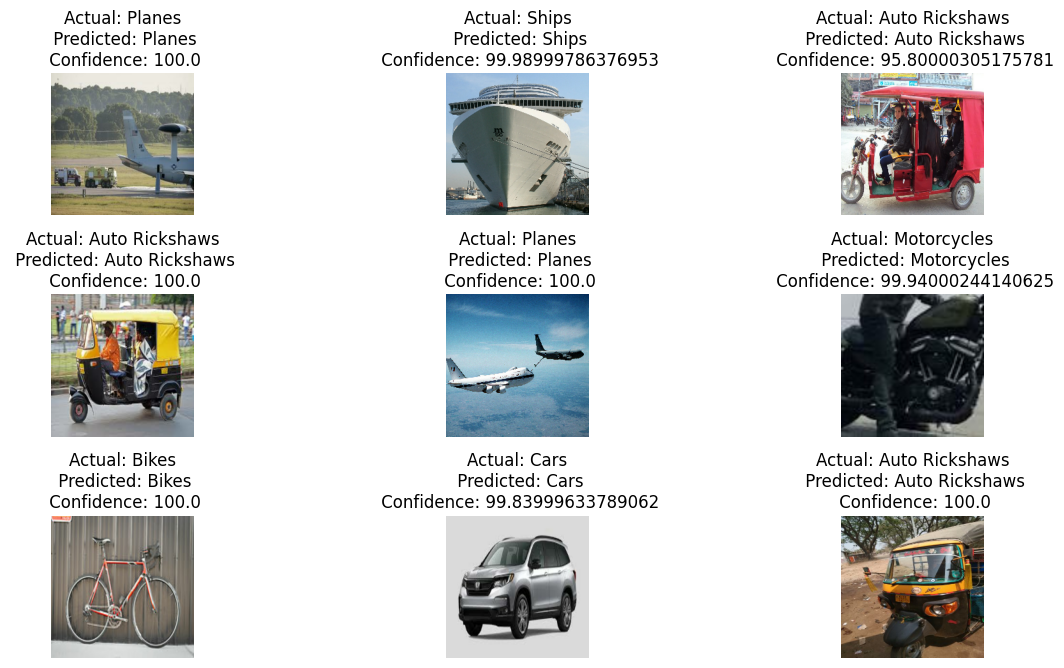

In [27]:
def predict(model, img):
    img_array = img_to_array(img)               # (224, 224, 3)
    img_array = tf.expand_dims(img_array, 0)   # (1, 224, 224, 3) batch input required
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = round(100*(np.max(prediction[0])),2)
    return predicted_class, confidence

plt.figure(figsize = (12,9))
for image, label in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(4,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        predicted_class, confidence = predict(model, image[i].numpy())
        actual_class = class_names[label[i]]
        plt.title(f"Actual: {actual_class}\n Predicted: {predicted_class}\n Confidence: {confidence}")
        plt.tight_layout()
        plt.axis('off')

## Save Model

In [29]:
model.save("models/model.h5")

In [32]:
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)